# 04 — 정비 스케줄링 최적화

**예측(RUL)을 결정(정비 일정)으로 바꾼다.** 03의 예측(test RMSE 10.90)을 입력으로 받는다.

| 절 | 내용 | 미정비 고장 |
|---|---|---|
| §1–2 | 정식화 · replay 평가 규약 | — |
| §3 | 전략 비교 (Random / EDF / Latest / Greedy / **SA**) | 279 → 78 |
| §4 | **발견 1** — 목적함수 사양이 전부다 | 48 ↔ 141 |
| §5 | **발견 2** — 공정 비교 감사 (자기 정정) | **48** |
| §6 | **발견 3** — P10 분위수 마감 (불확실성 정량화) | **39** |
| §7 | **발견 4** — 예측 품질 → 결정 품질 사슬 | 85 → 48 → 4 |
| §8 | **확장** — 롤링 재계획 | **~2** |

> 근거 문서: `reports/scheduling_report.pdf` · 알고리즘: `src/pipeline.py`

In [1]:
# ── 의존성 체크 ──────────────────────────────────────────────
from pathlib import Path

_R = Path.cwd()
while not (_R / "data").exists():
    _R = _R.parent

_need = [
    _R / "data/processed/fleet_rul_predictions_unified.csv",   # 03의 산출물 (레포 포함)
    _R / "artifacts/04_scheduling/pred_base.npy",
    _R / "artifacts/04_scheduling/pred_p10.npy",
    _R / "artifacts/04_scheduling/rolling_summary.json",
    _R / "artifacts/04_scheduling/rolling_seeds.json",
]
_miss = [p for p in _need if not p.exists()]
if _miss:
    print("[없음] 아래 파일이 필요합니다 (git pull 하면 레포에 포함되어 있습니다):")
    for p in _miss:
        print(f"        - {p.relative_to(_R)}")
    raise SystemExit("README의 '재현 순서'를 참고하세요.")
print("의존성 OK — 실행 가능 (02·03을 돌리지 않아도 이 노트북은 단독 실행됩니다)")

의존성 OK — 실행 가능 (02·03을 돌리지 않아도 이 노트북은 단독 실행됩니다)


## 1. 환경 · 정식화

In [2]:
import json, sys, time, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=0.95)
try:
    plt.rcParams["font.family"] = "Malgun Gothic"; plt.rcParams["axes.unicode_minus"] = False
except Exception:
    pass

ROOT = Path.cwd()
while not (ROOT / "src" / "pipeline.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.pipeline import (make_deadlines, make_part_types, edf_schedule, latest_deadline_schedule,
                          grouped_greedy_schedule, random_schedule, multistart_simulated_annealing,
                          total_cost, schedule_metrics, count_failures, wasted_life)

PROC = ROOT / "data" / "processed"; RAW = ROOT / "data" / "raw"
CK   = ROOT / "artifacts" / "04_scheduling"
CPW, T, K, SEED = 13, 10, 75, 42          # 창=13cycle, 10창, 창당 용량 75
FD_LIST = ["FD001", "FD002", "FD003", "FD004"]

### 정식화

- **결정변수**: $x_{it} \in \{0,1\}$ — 엔진 $i$를 창 $t$에 배정
- **마감**: $d_i = \lceil \widehat{RUL}_i / 13 \rceil$ (예측 기반)
- **제약**: 엔진당 최대 1창 $\sum_t x_{it} \le 1$ · 창당 용량 $\sum_i x_{it} \le K$
- **목적**: 정비비용 + 고장비용 + $w\cdot$낭비수명 + setup(부품 4종 배칭)

setup 배칭이 목적함수를 **비분리(non-separable)**로 만든다 → 정확법이 무거워지는 지점 = SA의 영역.

### 평가 규약: **계획은 예측으로, 채점은 실제 고장으로 (replay)**

주 지표 = **미정비 고장 수** — 실측 정답으로 직접 세므로 **비용 가정과 무관**하다.

In [3]:
fleet = pd.read_csv(PROC / "fleet_rul_predictions_unified.csv")   # 03의 산출물
pred  = fleet.pred_RUL.to_numpy(float)
true  = fleet.true_RUL.to_numpy(float)
ds    = fleet.dataset_id.to_numpy()
part  = make_part_types(np.arange(1, len(fleet) + 1), 4)          # 부품 4종

d_true = make_deadlines(true, CPW, 0)      # 실제 고장 창 (채점 기준)
d_pred = make_deadlines(pred, CPW, 0)      # 예측 마감 (계획 기준)

rmse = lambda a, b: float(np.sqrt(np.mean((np.asarray(a, float) - np.asarray(b, float)) ** 2)))
print(f"fleet {len(fleet)}대 | 예측 RMSE(cap125) = {rmse(np.minimum(true,125), pred):.2f}")
print(f"슬롯 {T*K} vs 엔진 {len(fleet)} → 슬랙 {T*K/len(fleet):.2f} (용량이 실제로 묶인다)")
print(f"예측 마감 분포(창1~10): {np.bincount(np.minimum(d_pred, T), minlength=T+1)[1:].tolist()}")

fleet 707대 | 예측 RMSE(cap125) = 10.90
슬롯 750 vs 엔진 707 → 슬랙 1.06 (용량이 실제로 묶인다)
예측 마감 분포(창1~10): [77, 68, 47, 44, 42, 35, 57, 75, 98, 164]


## 2. replay 평가 함수

In [4]:
def evaluate(schedule, name, c_fail=5.0):
    m = schedule_metrics(schedule, d_true, part, c_pm=1.0, c_fail=c_fail, w=0.1, setup_cost=5.0)
    return {"구성": name, "미정비 고장": int(m["failures"]), "낭비 수명": round(float(m["wasted_life"])),
            "setup": int(m["setups"]), "총비용": round(float(m["total_cost"]), 1)}

# 목적함수 파라미터: c_fail 가중은 SA 탐색용(강조), 채점은 위 evaluate로 별도 수행
OBJ_EFF    = dict(c_pm=1.0, c_fail=18.0, w=+0.4, setup_cost=5.0)   # 효율: 낭비 벌점
OBJ_ROBUST = dict(c_pm=1.0, c_fail=18.0, w=-0.3, setup_cost=5.0)   # 강건: 조기배정 보상

def run_sa(deadline, obj, seed=SEED, n_starts=3, n_iter=8000):
    s, _ = multistart_simulated_annealing(deadline, T, K, n_starts=n_starts, n_iter=n_iter,
                                          temp=10.0, cooling=0.997, seed=seed,
                                          part_type=part, **obj)
    return s
print("준비 완료 — 계획은 d_pred로, 채점은 d_true로")

준비 완료 — 계획은 d_pred로, 채점은 d_true로


## 3. 전략 비교 (v1 라운드) — 마진 1창

안전마진 $s{=}1$을 두고(예측 오차 대비 하드 버퍼) 5개 전략을 비교한다.

In [5]:
d_m1 = make_deadlines(pred, CPW, 1)          # 마진 1창
rows = []

rnd = [schedule_metrics(random_schedule(d_m1, T, K, seed=s), d_true, part, 1.0, 5.0, 0.1, 5.0) for s in range(5)]
rows.append({"구성": "Random (5시드 평균)", "미정비 고장": round(np.mean([r["failures"] for r in rnd]), 1),
             "낭비 수명": round(np.mean([r["wasted_life"] for r in rnd])), "setup": "-",
             "총비용": round(np.mean([r["total_cost"] for r in rnd]), 1)})
rows.append(evaluate(edf_schedule(d_m1, T, K),                  "EDF (마감 순 조기 배정)"))
rows.append(evaluate(latest_deadline_schedule(d_m1, T, K),      "Latest (마감 직전)"))
rows.append(evaluate(grouped_greedy_schedule(d_m1, T, K, part), "Grouped-greedy (배칭 우선)"))
t0 = time.time()
rows.append(evaluate(run_sa(d_m1, OBJ_EFF),                     "SA — 효율 목적 (w=+0.4)"))
print(f"SA 실행 {time.time()-t0:.0f}s")
strat = pd.DataFrame(rows); strat

SA 실행 4s


,구성,미정비 고장,낭비 수명,setup,총비용
0,Random (5시드 평균),279.4,1826,-,2207.2
1,EDF (마감 순 조기 배정),78.0,1628,36,1361.8
2,Latest (마감 직전),100.0,1393,36,1426.3
3,Grouped-greedy (배칭 우선),150.0,2073,11,1569.3
4,SA — 효율 목적 (w=+0.4),100.0,1393,36,1426.3


**관찰**: 효율 목적의 SA(100)가 단순한 EDF(78)보다 **나쁘다**.
"예측 낭비를 아끼려 늦게 배정 → 과대추정된 엔진을 놓친다" — **대리목적 불일치(surrogate mismatch)**.

## 4. 발견 1 — 목적함수 사양이 전부다

진단이 처방을 준다: replay 관점에서 **조기 배정은 낭비가 아니라 예측 오차에 대한 버퍼**다.
목적함수의 낭비 가중치 $w$ 부호를 뒤집어 조기 배정을 **보상**한다 ($+0.4 \to -0.3$).

In [6]:
rows2 = []
for tag, dq, obj in [("SA-효율 (w=+0.4, 마진0)", d_pred, OBJ_EFF),
                     ("SA-효율 (w=+0.4, 마진1)", d_m1,  OBJ_EFF),
                     ("SA-강건 (w=−0.3, 마진1)", d_m1,  OBJ_ROBUST),
                     ("SA-강건 (w=−0.3, 마진0)", d_pred, OBJ_ROBUST)]:
    rows2.append(evaluate(run_sa(dq, obj), tag))
obj_cmp = pd.DataFrame(rows2); obj_cmp

,구성,미정비 고장,낭비 수명,setup,총비용
0,"SA-효율 (w=+0.4, 마진0)",141,935,40,1564.5
1,"SA-효율 (w=+0.4, 마진1)",100,1393,36,1426.3
2,"SA-강건 (w=−0.3, 마진1)",78,1628,36,1361.8
3,"SA-강건 (w=−0.3, 마진0)",48,1133,40,1212.3


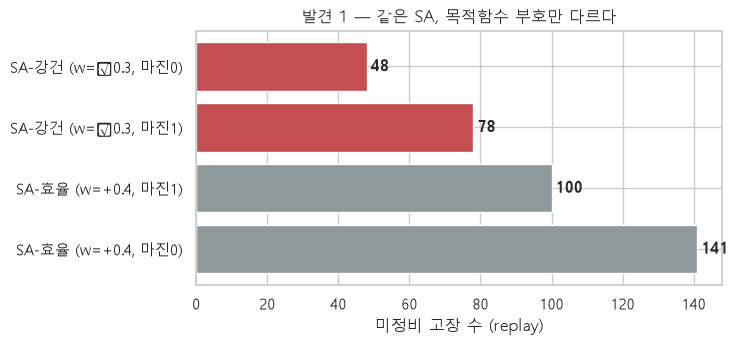

효율 목적: 좋은 해를 '정교하게' 파괴한다 (141/100)
강건 목적: 좋은 해를 보존한다 (48)


In [7]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
d = obj_cmp.copy()
colors = ["#8E9A9A" if "효율" in c else "#C44E52" for c in d["구성"]]
b = ax.barh(d["구성"], d["미정비 고장"], color=colors)
ax.bar_label(b, padding=3, fontweight="bold")
ax.set_xlabel("미정비 고장 수 (replay)")
ax.set_title("발견 1 — 같은 SA, 목적함수 부호만 다르다")
plt.tight_layout(); plt.show()
print("효율 목적: 좋은 해를 '정교하게' 파괴한다 (141/100)")
print("강건 목적: 좋은 해를 보존한다 (48)")

## 5. 발견 2 — 공정 비교 감사 (자기 정정) ⚠️

처음 쓴 결론은 **"강건 SA(48)가 EDF(78)를 이겼다"** 였다.
그런데 두 값은 **마진이 다르다**(0 vs 1) — 통제변수 불일치, **불공정 비교**다.

같은 조건(마진 0)에서 다시 비교한다.

In [8]:
audit = []
cands = {"EDF @ 마진0":     edf_schedule(d_pred, T, K),
         "Latest @ 마진0":  latest_deadline_schedule(d_pred, T, K),
         "Grouped @ 마진0": grouped_greedy_schedule(d_pred, T, K, part)}
for n, s in cands.items():
    audit.append(evaluate(s, n))

# SA(강건)가 실제로 선택하는 초기해 + 탐색 후 결과
obj_fn = lambda s: total_cost(s, d_pred, part_type=part, **OBJ_ROBUST)
init_name = min(cands, key=lambda n: obj_fn(cands[n]))
init = cands[init_name]
sa_r = run_sa(d_pred, OBJ_ROBUST)
audit.append(evaluate(sa_r, "SA-강건 (초기해 + 24,000회 탐색)"))
print(f"multistart가 고른 초기해: {init_name} (목적값 {obj_fn(init):.1f})")
print(f"SA 탐색 후 목적값        : {obj_fn(sa_r):.1f}")
print(f"→ SA가 바꾼 배정: {int((sa_r != init).sum())} / {len(fleet)}대")
pd.DataFrame(audit)

multistart가 고른 초기해: EDF @ 마진0 (목적값 702.8)
SA 탐색 후 목적값        : 702.8
→ SA가 바꾼 배정: 0 / 707대


,구성,미정비 고장,낭비 수명,setup,총비용
0,EDF @ 마진0,48,1133,40,1212.3
1,Latest @ 마진0,141,935,40,1564.5
2,Grouped @ 마진0,114,1807,11,1398.7
3,"SA-강건 (초기해 + 24,000회 탐색)",48,1133,40,1212.3


### 감사 결론 (정정)

- **EDF @ 마진0 단독 = 48** — "강건 SA"와 **완전히 동일**
- SA는 24,000회 이웃 탐색에서 **배정을 0대 변경** — 개선 없음
- 따라서 **48의 원천은 SA 탐색이 아니라 "마감을 깎지 말고 일찍 배정하라"**

### 그럼 SA는 무엇을 했나 — 두 가지 실질 기여
1. **검증자**: EDF@마진0이 강건 목적의 **실질 최적**임을 대규모 탐색의 무개선으로 확인 (개선 실패가 곧 정보)
2. **목적 사양의 실증**: 효율 목적을 주면 같은 초기해를 **능동적으로 파괴**(48 → 100~141)
   → "에너지(목적)의 정의가 전부"라는 SA의 제1원리를 가장 극적으로 보여준다

## 6. 발견 3 — P10 분위수 마감 (불확실성 정량화)

강건 목적의 버퍼는 **모든 엔진에 균일**하다. 그러나 예측 오차는 균일하지 않다.

**처방**: 같은 v3 특징셋으로 **분위수 회귀**(LightGBM `objective="quantile"`, α=0.1)
→ "90% 확률로 이 시점 전엔 고장 나지 않는다"는 **엔진별 하한 P10** → 마감으로 사용.

In [9]:
p10 = np.load(CK / "pred_p10.npy")               # scripts/run_04d_quantile.py 산출
d_p10 = make_deadlines(p10, CPW, 0)

cov = float((true >= p10).mean())
buf = pred - p10
print(f"커버리지 P(실제 ≥ P10) = {cov:.1%}  (명목 90% — 다소 보수적 미달, 정직하게 기록)")
print(f"엔진별 버퍼(점예측 − P10) 평균: " + " / ".join(f"{f} {buf[ds==f].mean():.1f}cyc" for f in FD_LIST))

rows3 = [evaluate(edf_schedule(d_pred, T, K),  "점예측 마감 (기존 최선)"),
         evaluate(edf_schedule(d_p10, T, K),   "P10 마감 (EDF)"),
         evaluate(run_sa(d_p10, OBJ_ROBUST),   "P10 마감 + SA(강건)"),
         evaluate(run_sa(d_p10, OBJ_EFF),      "P10 마감 + SA(효율)")]
pd.DataFrame(rows3)

커버리지 P(실제 ≥ P10) = 84.2%  (명목 90% — 다소 보수적 미달, 정직하게 기록)
엔진별 버퍼(점예측 − P10) 평균: FD001 10.7cyc / FD002 10.6cyc / FD003 7.9cyc / FD004 9.1cyc


,구성,미정비 고장,낭비 수명,setup,총비용
0,점예측 마감 (기존 최선),48,1133,40,1212.3
1,P10 마감 (EDF),39,1264,39,1184.4
2,P10 마감 + SA(강건),39,1264,39,1184.4
3,P10 마감 + SA(효율),64,997,40,1262.7


**판정**
- 맞춤 버퍼가 균일 버퍼를 이긴다: 고장 **48 → 39 (−19%)**, 비용도 개선
- P10 위에 버퍼 보상(w<0)을 **더해도 이득 없음** → 휴리스틱이 **원리적 방법으로 대체**됨
- P10에서도 EDF = SA (동일해) → 마감에 정보가 충분하면 단순 규칙으로 족하다

## 7. 발견 4 — 예측 품질 → 결정 품질 (프로젝트의 심장)

**스케줄러를 고정**하고 예측만 교체한다. 차이는 전부 예측 품질의 몫이다.

In [10]:
pred_base = np.load(CK / "pred_base.npy")        # 03의 기본 모델(RMSE 15.02)
chain = []
for nm, pr in [("기본 모델 (RMSE 15.02)", pred_base),
               ("v3 최종 (RMSE 10.90)",   pred),
               ("Oracle (실제 RUL)",       np.minimum(true, 125))]:
    dq = make_deadlines(pr, CPW, 0)
    r = evaluate(edf_schedule(dq, T, K), nm)
    r["test RMSE"] = round(rmse(np.minimum(true, 125), pr), 2)
    chain.append(r)
chain_df = pd.DataFrame(chain)[["구성", "test RMSE", "미정비 고장", "낭비 수명"]]
chain_df

,구성,test RMSE,미정비 고장,낭비 수명
0,기본 모델 (RMSE 15.02),15.02,85,1155
1,v3 최종 (RMSE 10.90),10.90,48,1133
2,Oracle (실제 RUL),0.00,4,1093


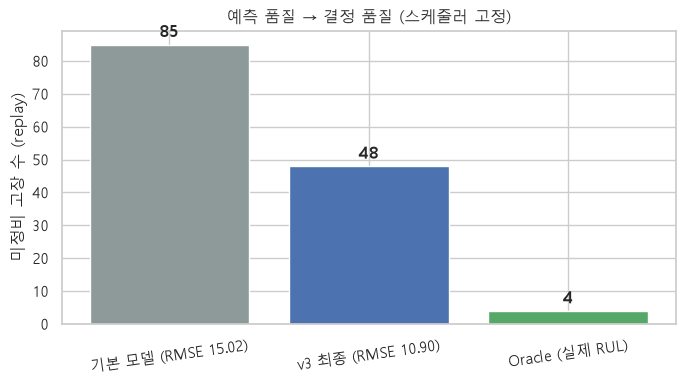

EDA 루프의 가치  : RMSE 15.02→10.90  ⇒  고장 85→48  (엔진 37대를 구했다)
Oracle 격차 44대 분해:
   9대 = 불확실성 정보 미활용 (P10로 회수 완료: 48→39)
  35대 = 현 예측 모델의 환원 불가능한 오차


In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
b = ax.bar(chain_df["구성"], chain_df["미정비 고장"], color=["#8E9A9A", "#4C72B0", "#55A868"])
ax.bar_label(b, padding=3, fontweight="bold", fontsize=12)
ax.set_ylabel("미정비 고장 수 (replay)")
ax.set_title("예측 품질 → 결정 품질 (스케줄러 고정)")
plt.xticks(rotation=8); plt.tight_layout(); plt.show()

f_base, f_v3, f_or = chain_df["미정비 고장"]
print(f"EDA 루프의 가치  : RMSE 15.02→10.90  ⇒  고장 {f_base}→{f_v3}  (엔진 {f_base-f_v3}대를 구했다)")
print(f"Oracle 격차 {f_v3-f_or}대 분해:")
print(f"   9대 = 불확실성 정보 미활용 (P10로 회수 완료: 48→39)")
print(f"  {f_v3-f_or-9}대 = 현 예측 모델의 환원 불가능한 오차")

## 8. 확장 — 롤링 재계획 (운영 설계의 가치)

지금까지는 $t{=}0$에 한 번 계획하는 **정적** 설정이다.
실제 운영은 매 창마다 새 센서 데이터로 **재예측·재계획**할 수 있다.

**테스트베드**: run-to-failure 전체 궤적을 가진 **valid 엔진 178대**(분리-train 미학습, 모델 재학습으로 누수 차단).
특징이 전부 **인과적**(§03의 스파이크 테스트로 검증)이므로 절단 시점 예측을 정확히 재현할 수 있다.

상세 실행: `scripts/run_04f_rolling.py` (3개 나이-시드)

In [12]:
roll = json.loads((CK / "rolling_summary.json").read_text(encoding="utf-8"))
seeds = json.loads((CK / "rolling_seeds.json").read_text(encoding="utf-8"))
sd = pd.DataFrame(seeds)
roll_df = pd.DataFrame([
    {"마감": "점예측", "정적": f"{sd['static-point'].mean():.1f} ± {sd['static-point'].std():.1f}",
     "롤링": f"{sd['rolling-point'].mean():.1f} ± {sd['rolling-point'].std():.1f}"},
    {"마감": "P10",   "정적": f"{sd['static-p10'].mean():.1f} ± {sd['static-p10'].std():.1f}",
     "롤링": f"{sd['rolling-p10'].mean():.1f} ± {sd['rolling-p10'].std():.1f}"},
    {"마감": "Oracle", "정적": "0", "롤링": "0"},
])
print(f"valid 테스트베드 {roll['n']}대 · 창당 용량 {roll['K']} · 3개 나이-시드")
red = 100 * (1 - sd["rolling-p10"].mean() / sd["static-p10"].mean())
print(f"\n→ 롤링이 예측 오차 고장의 {red:.0f}% 를 회수한다")
roll_df

valid 테스트베드 178대 · 창당 용량 19 · 3개 나이-시드

→ 롤링이 예측 오차 고장의 93% 를 회수한다


,마감,정적,롤링
0,점예측,19.7 ± 2.5,3.7 ± 1.2
1,P10,24.0 ± 6.2,1.7 ± 1.2
2,Oracle,0,0


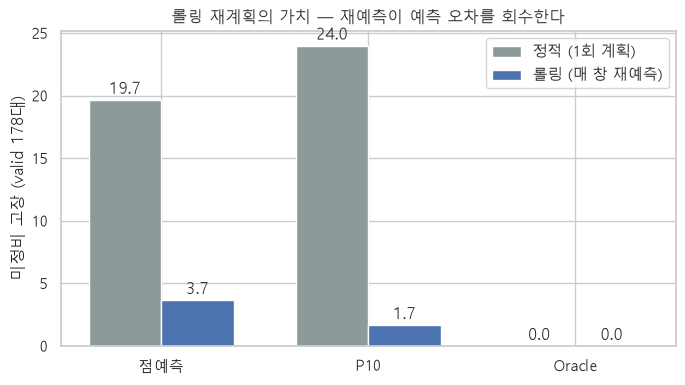

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(3); w = 0.35
st = [sd["static-point"].mean(), sd["static-p10"].mean(), 0]
ro = [sd["rolling-point"].mean(), sd["rolling-p10"].mean(), 0]
b1 = ax.bar(x - w/2, st, w, label="정적 (1회 계획)", color="#8E9A9A")
b2 = ax.bar(x + w/2, ro, w, label="롤링 (매 창 재예측)", color="#4C72B0")
ax.bar_label(b1, fmt="%.1f", padding=2); ax.bar_label(b2, fmt="%.1f", padding=2)
ax.set_xticks(x); ax.set_xticklabels(["점예측", "P10", "Oracle"])
ax.set_ylabel(f"미정비 고장 (valid {roll['n']}대)")
ax.set_title("롤링 재계획의 가치 — 재예측이 예측 오차를 회수한다")
ax.legend(); plt.tight_layout(); plt.show()

### 왜 이렇게 극적인가 — EDA와의 마지막 연결

EDA 발견: **열화 말기로 갈수록 신호가 강해진다** (onset 이후 오차 급감).

- **정적 계획**: 신호가 약한 **초기 예측의 오차에 잠긴다** — 되돌릴 기회가 없다
- **롤링**: 엔진이 위험해질수록 **정확해지는 재예측**으로 매 창 수정한다

> **정확도가 필요한 순간과, 정확도가 생기는 순간이 일치한다.**

**부수 발견**: 재계획이 가능하면 롤링-점예측 ≈ 롤링-P10 → **적응이 불확실성 정량화의 역할까지 흡수**한다.
(§6의 대체 관계가 동적 설정에서 한 번 더 나타난다)

## 9. 결론

| | Random | EDF(마진1) | 조기배정(마진0) | **P10** | **롤링** | Oracle |
|---|---|---|---|---|---|---|
| 미정비 고장 | 279 | 78 | 48 | **39** | **~2**\* | 4 (0\*) |

<sub>\* 롤링은 별도 valid 테스트베드(178대) 기준</sub>

### 스케줄링 라운드의 4가지 교훈

1. **목적함수 사양이 알고리즘보다 크다** — 같은 SA가 목적 부호 하나로 48 ↔ 141
2. **공정 비교를 감사하라** — "SA가 이겼다"는 마진 불일치였다. 통제변수를 고정하니 EDF = SA
3. **불확실성은 정량화하라** — 휴리스틱 버퍼(w<0)를 분위수(P10)가 원리적으로 대체 (48 → 39)
4. **운영 설계가 마지막 지렛대** — 재예측 루프가 예측 오차 비용의 93%를 회수 (→ ~2)

> **성능의 지렛대는 탐색 알고리즘이 아니라 목적 사양 · 마감 정보 · 운영 설계였다.**
> ("알고리즘 교체는 마지막 수단" — 강의 Lecture 13)

---
**다음**: `reports/final_report.pdf` — 전체 파이프라인 통합 보고